# Programa de Ciencia de Datos

Introducción a Machine Learning

Marlon Solano C.

## 1. Acceso a los datos

In [ ]:
# Librerías básicas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
datatrain =pd.read_csv('/content/sample_data/california_housing_train.csv', sep = ',')
datatrain.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
12620,-121.71,36.88,19.0,2528.0,554.0,2332.0,492.0,3.7766,177000.0
15208,-122.27,37.85,52.0,335.0,83.0,152.0,77.0,2.2841,106300.0
2139,-117.36,33.99,42.0,1178.0,261.0,804.0,283.0,2.9688,92900.0
9423,-119.23,34.27,29.0,3298.0,804.0,1509.0,711.0,3.8125,244500.0
1862,-117.27,32.82,35.0,2908.0,595.0,1068.0,529.0,4.1793,500001.0


In [ ]:
datatest =pd.read_csv('/content/sample_data/california_housing_test.csv', sep = ',')
datatest.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1834,-117.15,32.90,12.0,1681.0,381.0,1050.0,362.0,4.2008,176100.0
1294,-122.25,38.16,17.0,4459.0,944.0,1812.0,888.0,2.9375,106700.0
863,-117.69,33.58,8.0,2887.0,351.0,1176.0,351.0,10.3953,500001.0
2468,-122.49,37.68,34.0,3718.0,676.0,2510.0,632.0,5.3311,270800.0
1190,-117.28,34.26,18.0,3895.0,689.0,1086.0,375.0,3.3672,133600.0


In [ ]:
# Cantidad de datos

print("Tamaño de datos de entrenamiento: ", datatrain.shape, "85%")
print("Tamaño de datos de test: ", datatest.shape, "15%")

Tamaño de datos de entrenamiento:  (17000, 9) 85%
Tamaño de datos de test:  (3000, 9) 15%


## 2. Conjuntos de Entrenamiento, Valicación y Prueba & Validación-Cruzada.

* Es recomendable trabajar con una triple partición del universo de los datos: Entrenamiento, Validación y Prube.

## 3. Transformaciones durante el preprocesamiento

**Pipeline:** Gestionar el flujo de trabajo en la etapa de preprocesamiento.

* Imputación
* Escalamiento
* Transformaciones

In [ ]:
datatrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
sns.set(rc={'figure.figsize': (10,2)})

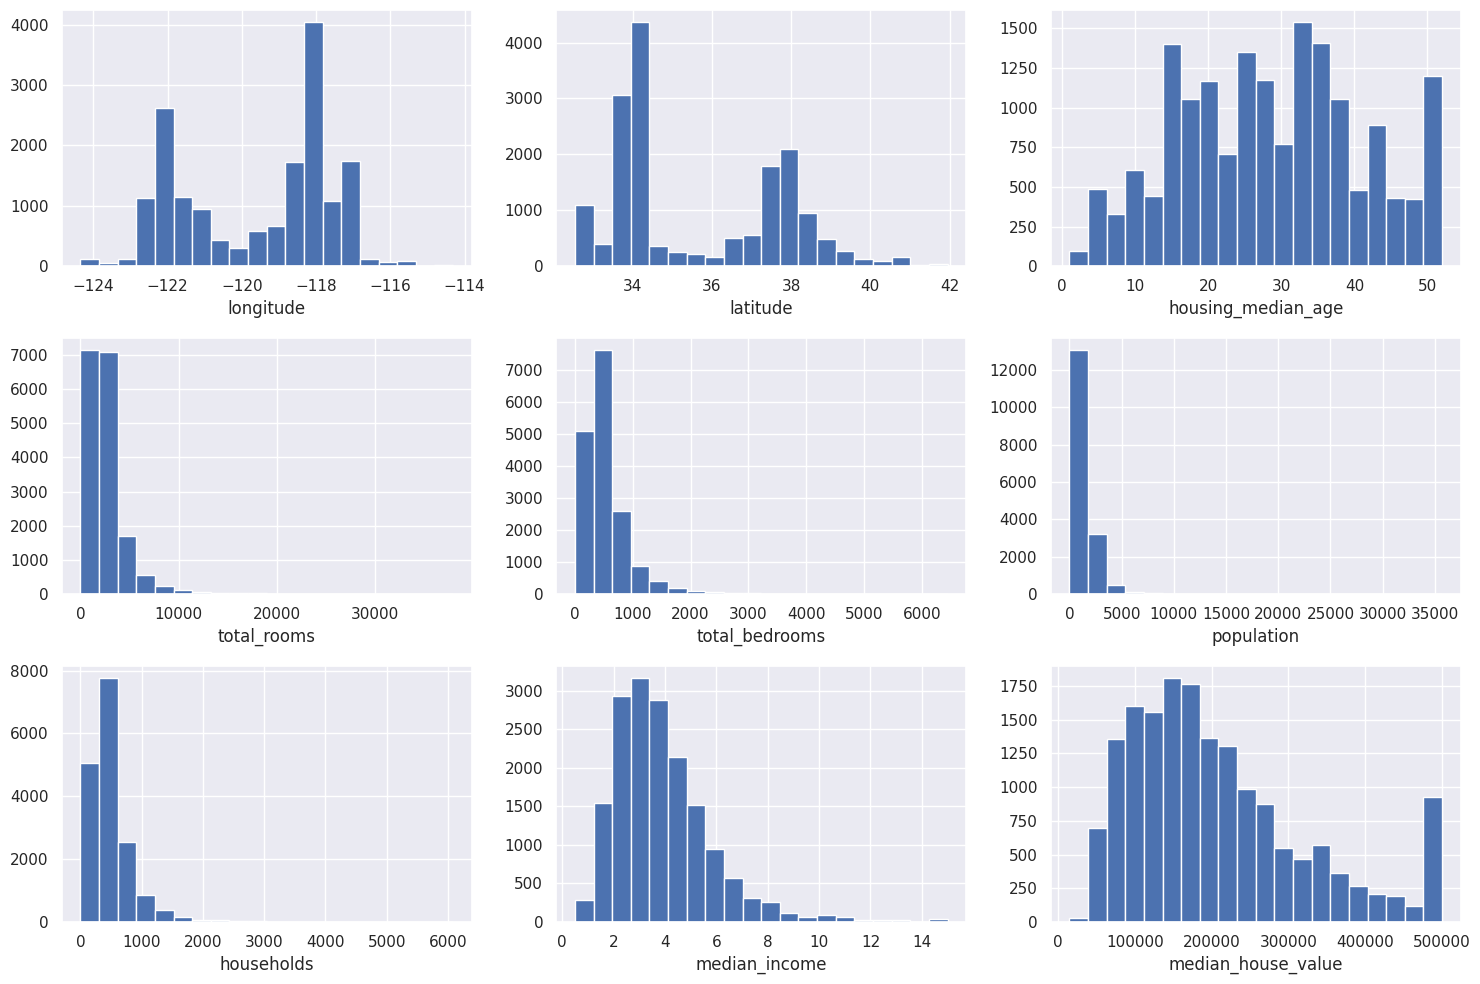

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))    # Definimos una ventana de 3x3 nichos para incluir en cada uno de ellos un gráfico.
for k in range(0,9):
  plt.subplot(3,3,k+1)     # Los nichos para cada histograma se numeran iniciando en 1.
  plt.hist(datatrain[datatrain.columns[k]], bins=20)     # datatrain.columns nos devuelve una lista con los nombres de las columnas.
  plt.xlabel(datatrain.columns[k])
plt.tight_layout()
plt.show()

In [ ]:
datatrain.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


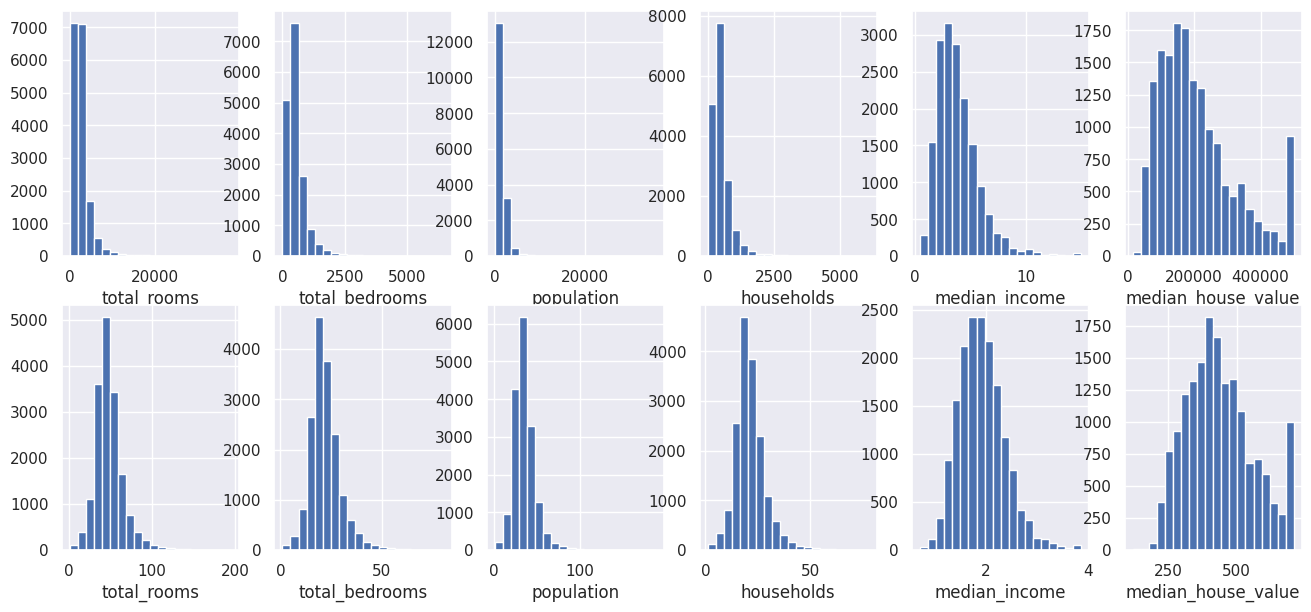

In [ ]:
sns.set(rc={'figure.figsize':(16,7)})

fig, axes = plt.subplots(2, 6)
for k in range(3,9):             # grafiquemos por el momento solo los factores con marcado sesgo positivo.
  plt.subplot(2,6,k-2)

  tmp = datatrain[datatrain.columns[k]]   # datos originales.
  plt.hist(tmp, bins=20)
  plt.xlabel(datatrain.columns[k])

  plt.subplot(2,6,k+4)
  tmp = np.sqrt(datatrain[datatrain.columns[k]])   # datos con alguna transformación para ajuste de la distribución.
  plt.hist(tmp, bins=20)
  plt.xlabel(datatrain.columns[k])

plt.show()

## 4. Métricas de desempeño

In [ ]:
# Definimos nuestra función del coeficiente de determinación ajustado a partir de las fórmulas dadas anteriormente, donde:
#    y_true: valores observados reales
#    y_hat : predicciones

# Suma de cuadrados de los errores:
def mi_SSE(y_true, y_hat):
  return sum( np.square(y_true - y_hat))

# Suma de cuadrados de la variabilidad total:
def mi_Syy(y_true, ymtrain):    # observa que se usa el valor promedio de las observaciones del conjunto de entrenamiento ymtrain.
  return sum( np.square(y_true - ymtrain))

# Coeficiente de determinación ajustado:
def mi_R2adj(sse, syy, n, k):
  tmp = ((n-1) / (n-k-1)) * (sse/syy)     # n:total de registros. k: total de variables independientes (predictores).
  return 1 - tmp    # coeficiente de determinación ajustado R2adj

## 5. Conjutando todos los pasos para el entrenamiento para el modelo RLM

In [ ]:
# Librerías

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import KFold

In [ ]:
# Con los datos de entrenamiento generamos algunos cambios
xtrain = datatrain.drop('median_house_value', axis='columns')

ytrain = datatrain['median_house_value']

# Hacemos lo mismo para los datos de prueba
Xtest = datatest.drop('median_house_value', axis='columns')

ytest = datatest['median_house_value']

Preprocesamiento:

In [ ]:
# Imputar con la mediana
# Escalar en un rango de (1 , 2)
num_prepro_pipeline = Pipeline(steps =[
  ('imputar', SimpleImputer(strategy='median')),
  ('escalar', MinMaxScaler(feature_range=(1,2)))
])

num_prepro_name = list(xtrain.columns)

# Transformación raíz cuadrada
num_raiz_pipeline = Pipeline(steps =[('sqrt', FunctionTransformer(np.sqrt))])

num_raiz_name = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# Ahora aplicamos todo el proceso en un solo pipeline:
columnasTransformer = ColumnTransformer(transformers=[
    ('num_prepro', num_prepro_pipeline, num_prepro_name),
    ('num_raiz', num_raiz_pipeline, num_raiz_name)
])

#

In [ ]:
modelo_LR = LinearRegression()

# Listas donde se van a guardar las particiones de entrenamiento y validación
scoresR2Train = []       # R2 del conjunto de entrenamiento.
scoresR2Val = []         # R2 del conjunto de validación con filtración.
scoresmiR2Val = []       # R2 del conjunto de validación sin filtración.
scoresmiR2adjVal = []    # R2 ajustada sin filtración.
scoresRMSEVal = []       # RMSE

# Inicializar la CV usando KFold
k = 5 # total de particiones (Fold)
kf = KFold(n_splits=k, shuffle=True)

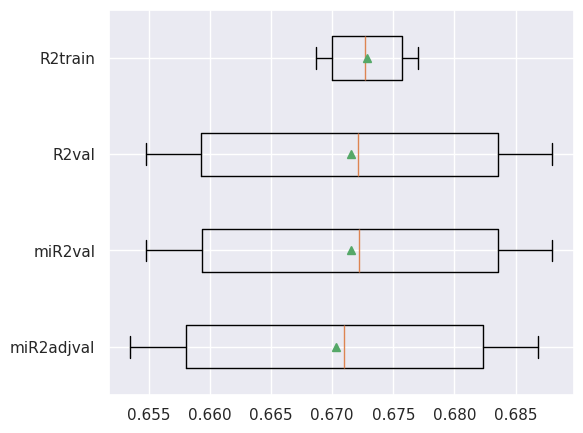

In [ ]:
import numpy as np
# Aplicamos validación-cruzada mediante la evaluación de cada una de las k particiones:
for train_index, val_index in kf.split(xtrain):
  # En cada partición definimos ahora sí el conjunto de entrenamiento y el de validación:
  X_train, X_val = xtrain.loc[train_index], xtrain.loc[val_index]
  y_train, y_val = ytrain[train_index], ytrain[val_index]
  # Aplicamos las transformaciones al conjunto de entrenamiento:
  XtrainFit = columnasTransformer.fit(X_train)   # Generamos la información necesaria con el conjunto de entrenamiento.
  XtrainTransf = XtrainFit.transform(X_train)    # y aplicamos dichas transformaciones al conjunto de entrenamiento,
  XvalTransf  =  XtrainFit.transform(X_val)      # y al conjunto de validación.
  ymtrain = np.mean(y_train)   # También requeriremos el promedio de las observaciones de entrenamiento para calcular Syy.
  # Generamos el modelo de regresión lineal con los datos de entrenamiento de esta partición:
  modelo_LR = modelo_LR.fit(XtrainTransf, y_train)
  scoresR2Train.append(modelo_LR.score(XtrainTransf,y_train))   # guardamos el desempeño R2 con los datos de entrenamiento.

  yhat = modelo_LR.predict(XvalTransf)  # obtenemos las predicciones con el conjunto de validación.
  scoresR2Val.append(modelo_LR.score(XvalTransf, y_val))   # guardamos los valores de R2, aunque en este caso hay filtración
                                                           # de datos ya que "score" hace aquí uso de del promedio de y_val.

  # Calcularemos el valor de R2 con nuestras fórmulas para mostrar que en este caso, aunque pequeña, hay filtración.
  # mi_R2:
  sse = mi_SSE(y_val, yhat)
  syy = mi_Syy(y_val, ymtrain)   # esta función evita la filtración de información al usar el promedio de los datos de entrenamiento.
  scoresmiR2Val.append(1 - sse/syy)
  # mi_R2_ajustada. Recordemos que en un problema de regresión lineal múltiple, es mejor considerar el valor ajustado de R2.
  tmp = mi_R2adj(sse,syy,XvalTransf.shape[0],XvalTransf.shape[1])
  scoresmiR2adjVal.append(tmp)
  # Calculamos también el error cuadrático medio RMSE a partir del MSE que nos da scikit-learn:
  ss = np.sqrt(mean_squared_error(y_val, yhat))
  scoresRMSEVal.append(ss)

# Mostremos los diagramas de caja de los resultados obtenidos:
results = [scoresmiR2adjVal,scoresmiR2Val,scoresR2Val,scoresR2Train]
names = ['miR2adjval','miR2val','R2val','R2train']
sns.set(rc={'figure.figsize':(6,5)})
plt.boxplot(results, tick_labels=names, showmeans=True, vert=False)
plt.show()

In [ ]:
# Despleguemos los resultados de los diferentes coeficientes de determinación obtenidos:
print("\t  %s \t%s   \t%s \t%s" % (names[3],names[2],names[1],names[0]))
for i,z in enumerate(zip(scoresR2Train, scoresR2Val, scoresmiR2Val, scoresmiR2adjVal)):
  print("fold[%d]:  %.4f \t%.4f  \t%.4f  \t%.4f" % (i+1,z[0],z[1],z[2],z[3]))
print("mean(std) %.3f(%.3f)  %.3f(%.3f)    %.3f(%.3f)    %.3f(%.3f)" % (np.mean(scoresR2Train), np.std(scoresR2Train),
                                                                        np.mean(scoresR2Val), np.std(scoresR2Val),
                                                                        np.mean(scoresmiR2Val), np.std(scoresmiR2Val),
                                                                        np.mean(scoresmiR2adjVal), np.std(scoresmiR2adjVal)))

	  R2train 	R2val   	miR2val 	miR2adjval
fold[1]:  0.6700 	0.6835  	0.6835  	0.6823
fold[2]:  0.6727 	0.6721  	0.6722  	0.6709
fold[3]:  0.6687 	0.6880  	0.6880  	0.6868
fold[4]:  0.6757 	0.6593  	0.6593  	0.6580
fold[5]:  0.6770 	0.6548  	0.6548  	0.6534
mean(std) 0.673(0.003)  0.672(0.013)    0.672(0.013)    0.670(0.013)


In [ ]:
# Y ahora despleguemos los valores de RMSE de validación de cada partición:
print("\t  RMSEval")
for i,s in enumerate(scoresRMSEVal):
  print("fold[%d]:  %.2f" % (i+1,s))
#print("\t %.2f (%.2f)" % (np.mean(scoresMSEVal), np.std(scoresMSEVal)))
print("mean(std) %.2f (%.2f)" % (np.mean(scoresRMSEVal), np.std(scoresRMSEVal)))

	  RMSEval
fold[1]:  65437.16
fold[2]:  66988.80
fold[3]:  65184.82
fold[4]:  67017.82
fold[5]:  67595.81
mean(std) 66444.88 (954.15)


# 6. Modelo final, conjunto de prueba (test) y conclusiones

In [ ]:
# Inicializamos de nuevo nuestro mejor modelo con sus parámetros predeterminados:
modelo_LRf = LinearRegression()
# Ajustamos las transformaciones con el conjunto de "entrenamiento aumentado", i.e., el train-set
# completo del archivo inicial, pero con los MISMOS PASOS que ya se decidieron en la etapa de entrenamiento previa:
XtrainTf = columnasTransformer.fit(xtrain)
XtrainFTf = XtrainTf.transform(xtrain)   # Aplicamos las mejores transformaciones  a los datos completos de train.
XtestFTf = XtrainTf.transform(Xtest)     # Aplicamos las transformaciones a Test con la información de Train para evitar la filtración.
                                         # Observa que esta es la primera vez que usamos los datos de prueba (Test) desde que iniciamos.
modelo_LRf = modelo_LRf.fit(XtrainFTf, ytrain)   # Entrenamos el mejor modelo con el conjunto de "entrenamiento aumentado".
yhatf = modelo_LRf.predict(XtestFTf)    # Generamos las predicciones con los datos de prueba (Test).
ymtrainf = np.mean(ytrain)     # Obtenemos el promedio de los datos de entrenamiento (recuerda que sklearn no nos regresa R2adj).
ssef = mi_SSE(ytest, yhatf)
syyf = mi_Syy(ytest, ymtrainf)
miR2adjf = mi_R2adj(ssef,syyf,XtestFTf.shape[0],XtestFTf.shape[1])   # Obtenemos R2adj con nuestra función que definimos previamente.
print("Métricas de desempeño del modelo final obtenido con el conjunto de prueba:")
print("Coeficiente de determinación ajustado: miR2adj = %.4f" % miR2adjf)
#print("Coeficiente de determinación R2 con filtración: %.4f" % modelo_LRf.score(XtestFTf, ytest))
RMSEtestf = np.sqrt(mean_squared_error(ytest, yhatf))
print("Raíz del error cuadrático medio: RMSE = %.2f" % RMSEtestf)

Métricas de desempeño del modelo final obtenido con el conjunto de prueba:
Coeficiente de determinación ajustado: miR2adj = 0.6396
Raíz del error cuadrático medio: RMSE = 67756.78
